# AG-HYPOPT · Trial 10

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Nine trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803; then trial_05 (sw 0.844, h_f 3.903, h_s 3.616, cap 0.217) 0.0822, trial_09 (sw 0.847, h_f 4.0, h_s 3.603, cap 0.231) 0.0839, trial_06 (sw 0.497, h_f 4.0, h_s 3.876, cap 0.104) 0.0861, trial_08 (sw 0.869, h_f 3.985, h_s 3.624, cap 0.295) 0.0876. All 0 diverged, gamma finite. The optimum region is a tight cluster: strong sigma weight (~0.85), kernels near their upper bounds (h_f ~3.9-4.0, h_s ~3.6-3.7), small gamma cap (~0.1); trials 08 and 09 both showed a larger cap hurts gamma. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_10'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (9/5 trials)
ID |     ei | params
 1 | 3.9874 | {"gamma_rel_cap": 0.177330049624657, "h_f_scale": 3.9161928421625847, "h_s_scale": 3.6782119240690774, "sigma_weight": 0.8531413613724996}
 2 | 3.9585 | {"gamma_rel_cap": 0.08267791892667242, "h_f_scale": 3.863538467645702, "h_s_scale": 3.6730603296343785, "sigma_weight": 0.8324485214882055}
 3 | 0.0187 | {"gamma_rel_cap": 0.37279010552196873, "h_f_scale": 3.6494828354234756, "h_s_scale": 3.4496490621460234, "sigma_weight": 0.9698303682063217}
 4 | 2.3317 | {"gamma_rel_cap": 0.00500121155653914, "h_f_scale": 2.521993734323785, "h_s_scale": 3.692796908599722, "sigma_weight": 0.24977551939628317}
 5 | 2.1160 | {"gamma_rel_cap": 0.1153217144365353, "h_f_scale": 0.8103058771787061, "h_s_scale": 1.1834535159681114, "sigma_weight": 0.8677239837623857}
 6 | 3.9606 | {"gamma_rel_cap": 0.20326786992521204, "h_f_scale": 3.9645125565556985, "h_s_scale": 3.689162261550008, "sigma_weight": 0.8767234666021806}
 7 | 3.6620 | {"gamma_rel_

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Optimum region: sw ~0.85, h_f ~3.9-4.0, h_s ~3.6-3.7, small gamma cap. Two trials (08, 09) showed that a larger cap (0.23-0.30) hurts gamma; the best cap so far is trial_07's 0.107, and the small side of the cap is unexplored. The top-ei draws are again near-copies of trial_07.

Candidate 2 (ei 3.9585) is nearly identical to trial_07 (sw 0.832 vs 0.865, h_f 3.864 vs 4.0, h_s 3.673 vs 3.675) but with a smaller gamma cap (0.0827 vs 0.107). It is the cleanest single-knob test of the cap hypothesis on the small side, which the larger-cap trials 08/09 suggest is the promising direction.

I choose candidate 2.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2               # candidate 2: sigma_weight 0.832, h_f_scale 3.864, h_s_scale 3.673, gamma_rel_cap 0.083 (trial_07-like, smaller cap)


chosen: {'gamma_rel_cap': 0.08267791892667242, 'h_f_scale': 3.863538467645702, 'h_s_scale': 3.6730603296343785, 'sigma_weight': 0.8324485214882055}
Running  1nW Trans05 ... 

μ 9.39 -> 6.11 | γ 8.5 -> 4.40 | NLL 0.26


Running  1nW Trans20 ... 

μ 17.32 -> 28.13 | γ 8.5 -> 5.43 | NLL 0.66


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 64.06 | γ 14.1 -> 14.05 | NLL 0.72


Running 3nW Trans100 ... 

μ 175.71 -> 97.89 | γ 14.1 -> 13.75 | NLL 0.70



Total: 7.7 min


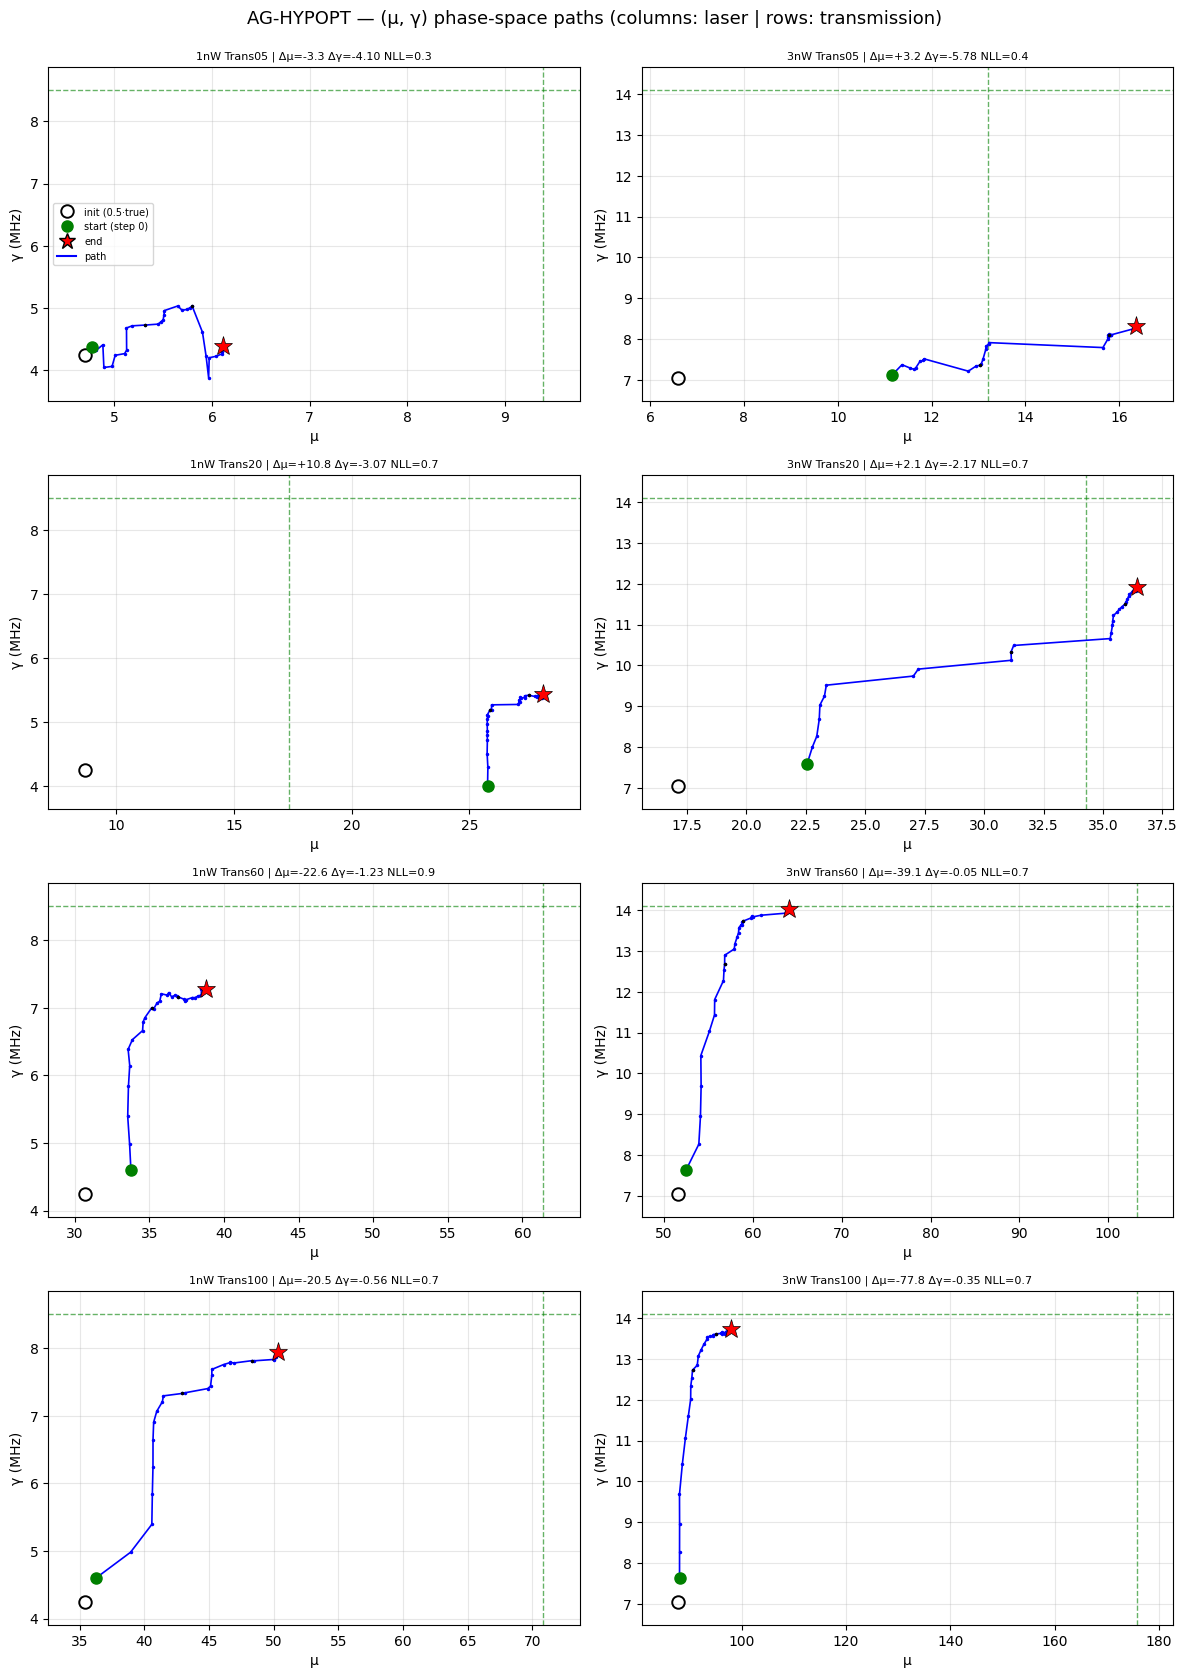

trial finished in 7.8 min
objective = 0.0922 ± 0.0268
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.11   -34.9 |     8.50    4.40   -48.3
1nW Trans20       17.32   28.13   +62.4 |     8.50    5.43   -36.1
1nW Trans60       61.37   38.82   -36.8 |     8.50    7.27   -14.4
1nW Trans100       70.82   50.36   -28.9 |     8.50    7.94    -6.6
3nW Trans05       13.20   16.36   +23.9 |    14.10    8.32   -41.0
3nW Trans20       34.28   36.41    +6.2 |    14.10   11.93   -15.4
3nW Trans60      103.20   64.06   -37.9 |    14.10   14.05    -0.4
3nW Trans100      175.71   97.89   -44.3 |    14.10   13.75    -2.5

weighted objective (T-graded, cap=1.0) = 0.0922 | diverged cells: 0
μ: RMSE 32.896 (rel 37.6%, bias -18.395) | γ: RMSE 2.879 (rel 26.9%, bias -2.164)


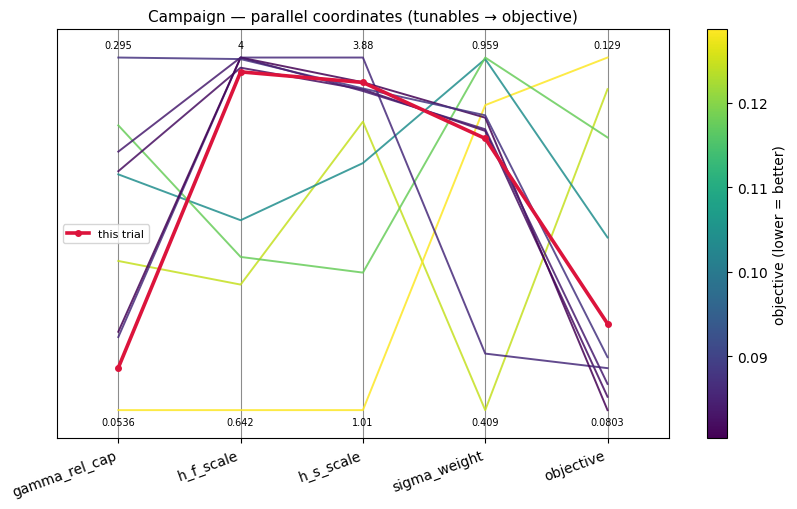

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 10 (sw 0.832, h_f 3.864, h_s 3.673, cap 0.083) ran to completion in 7.8 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0922 +/- 0.0268 - worse than trial_07 (0.0803) and now the highest of the trial_05/06/07/08/09/10 cluster.

mu rel-RMSE 37.6% (slightly worse than trial_07's 35.9%); same shape - high-T undershoot (3nW Trans100 -44.3%, 3nW Trans60 -37.9%, 1nW Trans60 -36.8%, 1nW Trans100 -28.9%), low-T overshoot (1nW Trans20 +62.4%, 3nW Trans05 +23.9%); bias -18.40.

gamma rel-RMSE 26.9% (worse than trial_07's 22.3%): low T under-estimated (1nW Trans05 -48.3%, 3nW Trans05 -41.0%, 1nW Trans20 -36.1%), high T near truth (-0.4%, -2.5%).

The candidate was the nearest trial_07 copy with a smaller gamma cap (0.0827 vs 0.107). Since trials 08 (0.295) and 09 (0.231) with larger caps were also worse, the gamma-cap optimum is now bracketed: both a smaller (0.083) and a larger (0.23-0.30) cap degrade the objective relative to ~0.1, so the best cap sits in a narrow band near trial_07's value.

**Summary:** Trial 10 (sw=0.832, h_f=3.864, h_s=3.673, cap=0.083) finished in 7.8 min with 0 diverged cells and gamma finite, objective 0.0922 +/- 0.0268 - worse than trial_07 (mu rel-RMSE 37.6%, gamma rel-RMSE 26.9%).
**Key insight:** A smaller gamma cap (0.083) also worsened the objective relative to trial_07 (0.107), so the gamma-cap optimum is a narrow band near ~0.1-0.15 rather than either extreme.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 10 (sw=0.832, h_f=3.864, h_s=3.673, cap=0.083): objective 0.0922 +/- 0.0268 - worse than trial_07; 0 diverged cells, gamma finite (mu rel-RMSE 37.6%, gamma rel-RMSE 26.9%).'
KEY_INSIGHT = 'A smaller gamma cap (0.083) also worsened the objective relative to trial_07 (0.107), so the gamma-cap optimum is a narrow band near ~0.1-0.15 rather than either extreme.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_10 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_11.ipynb. Open it and follow its cells from the top.
